In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

DATA_DIR = Path('../data')
PM_FEE = 0.02

In [2]:
def load(path):
    df = pq.read_table(path).to_pandas()
    df = df[df['resolved_yes'].notna()].copy()
    df['resolved_yes'] = df['resolved_yes'].astype(bool)
    df['opened_at'] = pd.to_datetime(df['opened_at'], utc=True)
    # won = side matches outcome
    df['won'] = ((df['side'] == 'YES') & df['resolved_yes']) | ((df['side'] == 'NO') & ~df['resolved_yes'])
    return df.sort_values('opened_at').reset_index(drop=True)

model = load(DATA_DIR / 'trades/model_trades.parquet')
analysis = load(DATA_DIR / 'trades/analysis_trades.parquet')

for df, label in [(model, 'Model'), (analysis, 'Analysis')]:
    yes = df[df['side']=='YES']
    no  = df[df['side']=='NO']
    print(f"{label}: {len(df):,} trades  "
          f"YES={len(yes):,} ({100*len(yes)/len(df):.0f}%)  "
          f"NO={len(no):,} ({100*len(no)/len(df):.0f}%)  "
          f"win={100*df['won'].mean():.1f}%  "
          f"pnl=${df['pnl'].sum():+.2f}  "
          f"markets={df['market_id'].nunique()}")

Model: 35,301 trades  YES=19,507 (55%)  NO=15,794 (45%)  win=48.3%  pnl=$-1401.92  markets=210
Analysis: 25,490 trades  YES=13,930 (55%)  NO=11,560 (45%)  win=51.9%  pnl=$-238.71  markets=211


## 1. Per-candle P&L
Trades within the same candle resolve identically — the real independent sample is the candle, not the trade.

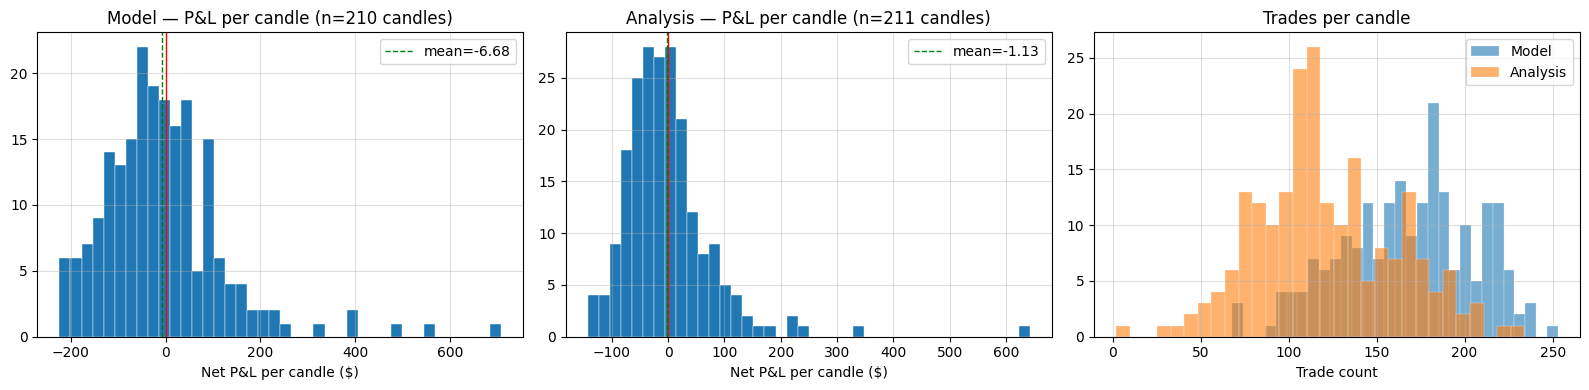

Model: 210 candles  profitable=93 (44%)  avg_pnl=-6.68  median=-25.10
Analysis: 211 candles  profitable=85 (40%)  avg_pnl=-1.13  median=-10.66


In [3]:
def candle_pnl(df):
    return df.groupby('market_id').agg(
        trades=('pnl', 'count'),
        net_pnl=('pnl', 'sum'),
        won=('won', 'mean'),
        yes_trades=('side', lambda s: (s=='YES').sum()),
        no_trades=('side', lambda s: (s=='NO').sum()),
    ).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, df, label in [(axes[0], model, 'Model'), (axes[1], analysis, 'Analysis')]:
    c = candle_pnl(df)
    ax.hist(c['net_pnl'], bins=40, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linewidth=1)
    ax.axvline(c['net_pnl'].mean(), color='green', linewidth=1, linestyle='--', label=f"mean={c['net_pnl'].mean():+.2f}")
    ax.set_title(f'{label} — P&L per candle (n={len(c)} candles)')
    ax.set_xlabel('Net P&L per candle ($)')
    ax.legend()

# trades per candle
ax = axes[2]
for df, label in [(model, 'Model'), (analysis, 'Analysis')]:
    c = candle_pnl(df)
    ax.hist(c['trades'], bins=30, alpha=0.6, label=label, edgecolor='white', linewidth=0.3)
ax.set_title('Trades per candle')
ax.set_xlabel('Trade count')
ax.legend()
plt.tight_layout()
plt.show()

for df, label in [(model, 'Model'), (analysis, 'Analysis')]:
    c = candle_pnl(df)
    pos = (c['net_pnl'] > 0).sum()
    print(f"{label}: {len(c)} candles  profitable={pos} ({100*pos/len(c):.0f}%)  avg_pnl={c['net_pnl'].mean():+.2f}  median={c['net_pnl'].median():+.2f}")

## 2. Edge size dependency
Does larger edge actually predict better outcomes?

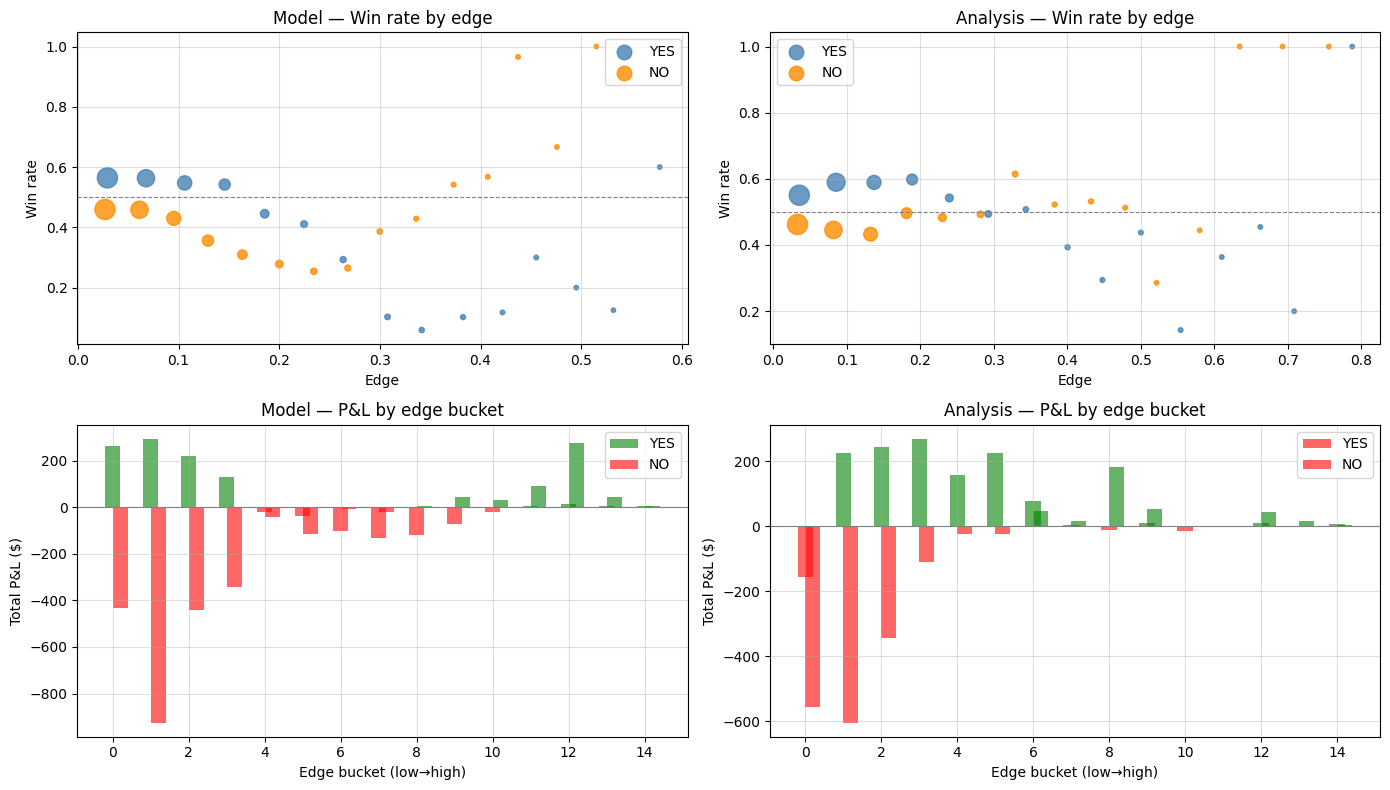

In [4]:
def edge_bins(df, n_bins=15):
    df = df.copy()
    df['edge_bin'] = pd.cut(df['edge'], bins=n_bins)
    return df.groupby('edge_bin', observed=True).agg(
        n=('won', 'count'),
        win_rate=('won', 'mean'),
        pnl=('pnl', 'sum'),
        mid_edge=('edge', 'mean'),
    ).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for col_i, (df, label) in enumerate([(model, 'Model'), (analysis, 'Analysis')]):
    for side, color in [('YES', 'steelblue'), ('NO', 'darkorange')]:
        sub = df[df['side'] == side]
        if len(sub) == 0:
            continue
        b = edge_bins(sub)
        axes[0][col_i].scatter(b['mid_edge'], b['win_rate'], s=b['n']/b['n'].max()*200+10,
                               color=color, alpha=0.8, label=side)
        axes[1][col_i].bar(range(len(b)), b['pnl'],
                           color=['green' if p >= 0 else 'red' for p in b['pnl']],
                           alpha=0.6, label=side, width=0.4,
                           align='center' if side == 'YES' else 'edge')

    axes[0][col_i].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    axes[0][col_i].set_title(f'{label} — Win rate by edge')
    axes[0][col_i].set_xlabel('Edge')
    axes[0][col_i].set_ylabel('Win rate')
    axes[0][col_i].legend()

    axes[1][col_i].set_title(f'{label} — P&L by edge bucket')
    axes[1][col_i].set_xlabel('Edge bucket (low→high)')
    axes[1][col_i].set_ylabel('Total P&L ($)')
    axes[1][col_i].axhline(0, color='gray', linewidth=0.8)
    axes[1][col_i].legend()

plt.tight_layout()
plt.show()

## 3. Time remaining dependency
When in the candle is edge most reliable?

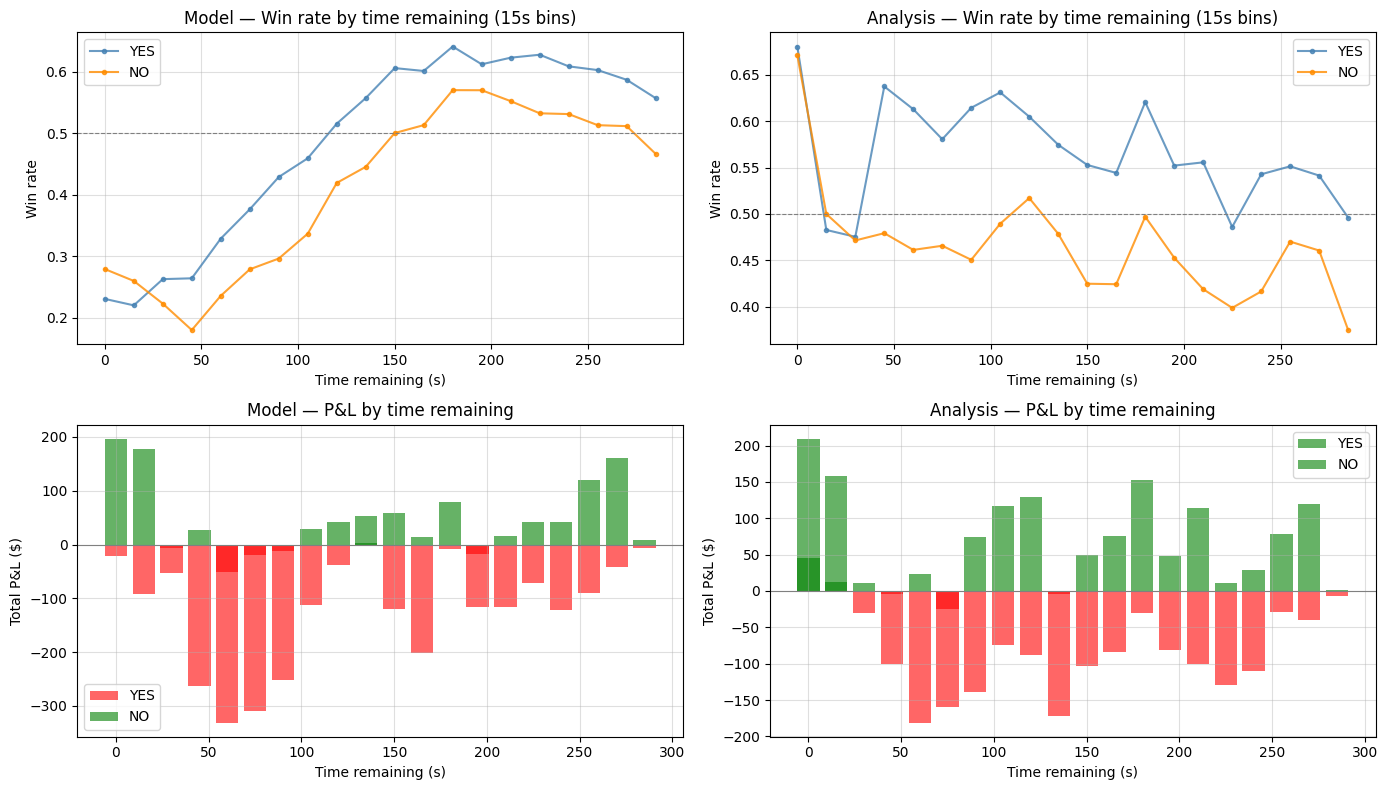

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col_i, (df, label) in enumerate([(model, 'Model'), (analysis, 'Analysis')]):
    df = df.copy()
    df['t_bucket'] = (df['time_remaining'] // 15) * 15

    for side, color in [('YES', 'steelblue'), ('NO', 'darkorange')]:
        sub = df[df['side'] == side]
        if len(sub) == 0:
            continue
        grp = sub.groupby('t_bucket').agg(
            n=('won', 'count'), win_rate=('won', 'mean'), pnl=('pnl', 'sum')
        ).reset_index()
        axes[0][col_i].plot(grp['t_bucket'], grp['win_rate'], marker='o', markersize=3,
                            color=color, label=side, alpha=0.8)
        bar_colors = ['green' if p >= 0 else 'red' for p in grp['pnl']]
        axes[1][col_i].bar(grp['t_bucket'], grp['pnl'], width=12,
                           color=bar_colors, alpha=0.6, label=side)

    axes[0][col_i].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    axes[0][col_i].set_title(f'{label} — Win rate by time remaining (15s bins)')
    axes[0][col_i].set_xlabel('Time remaining (s)')
    axes[0][col_i].set_ylabel('Win rate')
    axes[0][col_i].legend()

    axes[1][col_i].axhline(0, color='gray', linewidth=0.8)
    axes[1][col_i].set_title(f'{label} — P&L by time remaining')
    axes[1][col_i].set_xlabel('Time remaining (s)')
    axes[1][col_i].set_ylabel('Total P&L ($)')
    axes[1][col_i].legend()

plt.tight_layout()
plt.show()

## 4. BTC % change dependency
Does the direction or magnitude of BTC move correlate with edge quality?

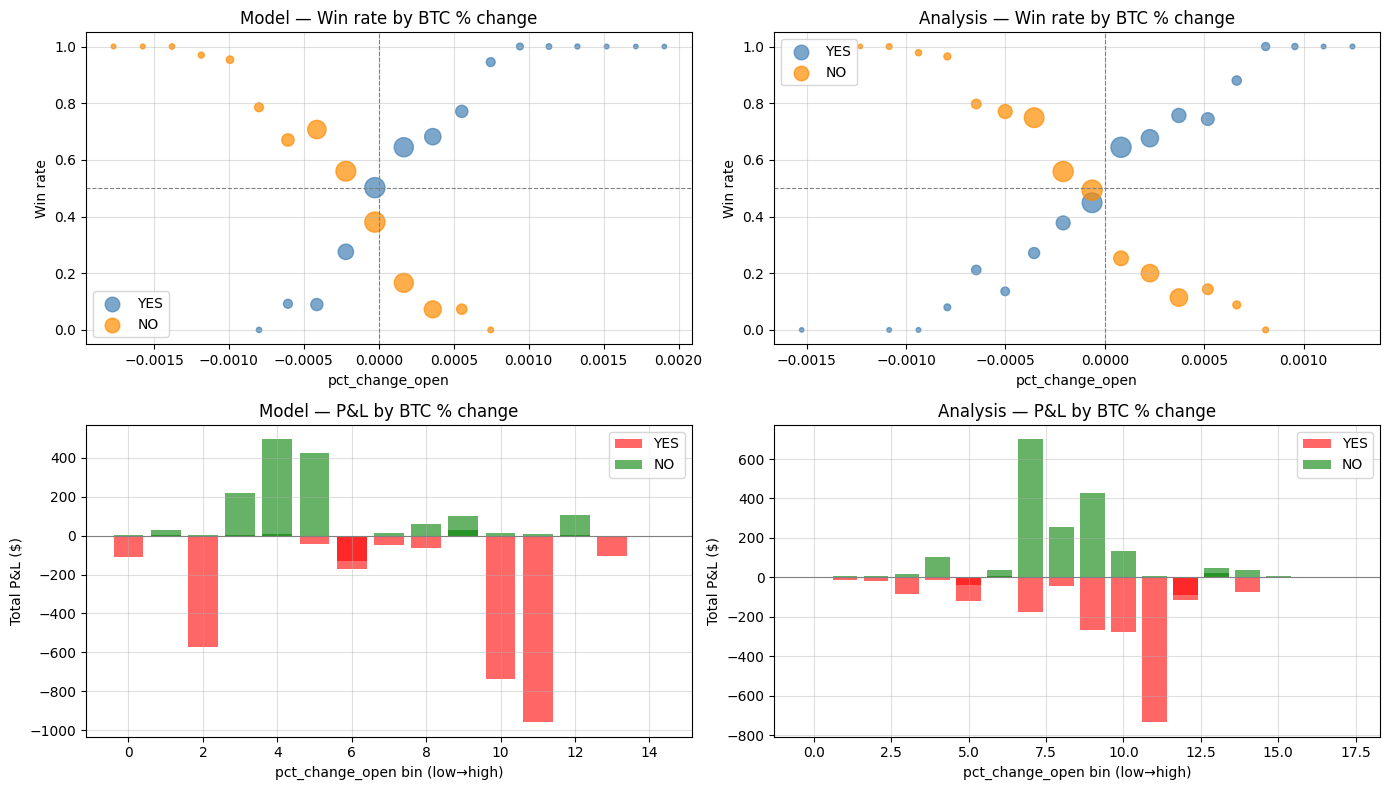

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col_i, (df, label) in enumerate([(model, 'Model'), (analysis, 'Analysis')]):
    df = df.copy()
    df['pct_bin'] = pd.cut(df['pct_change_open'], bins=20)
    df['pct_mid'] = df['pct_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)

    for side, color in [('YES', 'steelblue'), ('NO', 'darkorange')]:
        sub = df[df['side'] == side].dropna(subset=['pct_bin'])
        if len(sub) == 0:
            continue
        grp = sub.groupby('pct_bin', observed=True).agg(
            n=('won', 'count'), win_rate=('won', 'mean'), pnl=('pnl', 'sum'), mid=('pct_mid', 'first')
        ).reset_index().dropna()
        axes[0][col_i].scatter(grp['mid'], grp['win_rate'],
                               s=grp['n']/grp['n'].max()*200+10, color=color, alpha=0.7, label=side)
        bar_colors = ['green' if p >= 0 else 'red' for p in grp['pnl']]
        axes[1][col_i].bar(range(len(grp)), grp['pnl'], color=bar_colors, alpha=0.6, label=side)

    axes[0][col_i].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    axes[0][col_i].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0][col_i].set_title(f'{label} — Win rate by BTC % change')
    axes[0][col_i].set_xlabel('pct_change_open')
    axes[0][col_i].set_ylabel('Win rate')
    axes[0][col_i].legend()

    axes[1][col_i].axhline(0, color='gray', linewidth=0.8)
    axes[1][col_i].set_title(f'{label} — P&L by BTC % change')
    axes[1][col_i].set_xlabel('pct_change_open bin (low→high)')
    axes[1][col_i].set_ylabel('Total P&L ($)')
    axes[1][col_i].legend()

plt.tight_layout()
plt.show()

## 5. Predicted probability dependency
Does higher predicted probability translate to higher actual win rate?

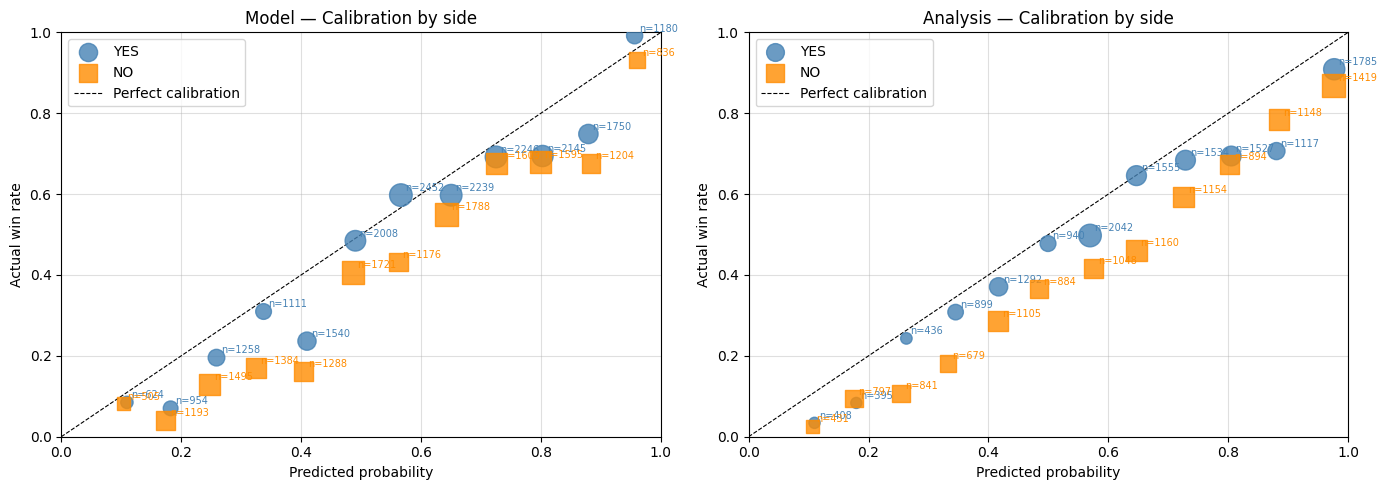

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label in [(axes[0], model, 'Model'), (axes[1], analysis, 'Analysis')]:
    for side, color, marker in [('YES', 'steelblue', 'o'), ('NO', 'darkorange', 's')]:
        sub = df[df['side'] == side].copy()
        if len(sub) == 0:
            continue
        sub['prob_bin'] = pd.cut(sub['predicted_prob'], bins=12)
        grp = sub.groupby('prob_bin', observed=True).agg(
            n=('won', 'count'), win_rate=('won', 'mean'), mean_prob=('predicted_prob', 'mean')
        ).dropna()
        ax.scatter(grp['mean_prob'], grp['win_rate'],
                   s=grp['n']/grp['n'].max()*250+15,
                   color=color, marker=marker, alpha=0.8, label=side, zorder=3)
        for _, row in grp.iterrows():
            ax.annotate(f"n={int(row['n'])}", (row['mean_prob'], row['win_rate']),
                        xytext=(3, 3), textcoords='offset points', fontsize=7, color=color)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Actual win rate')
    ax.set_title(f'{label} — Calibration by side')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Market price dependency
Does the absolute yes_price level affect edge quality? e.g. edge at yes=0.3 vs yes=0.7

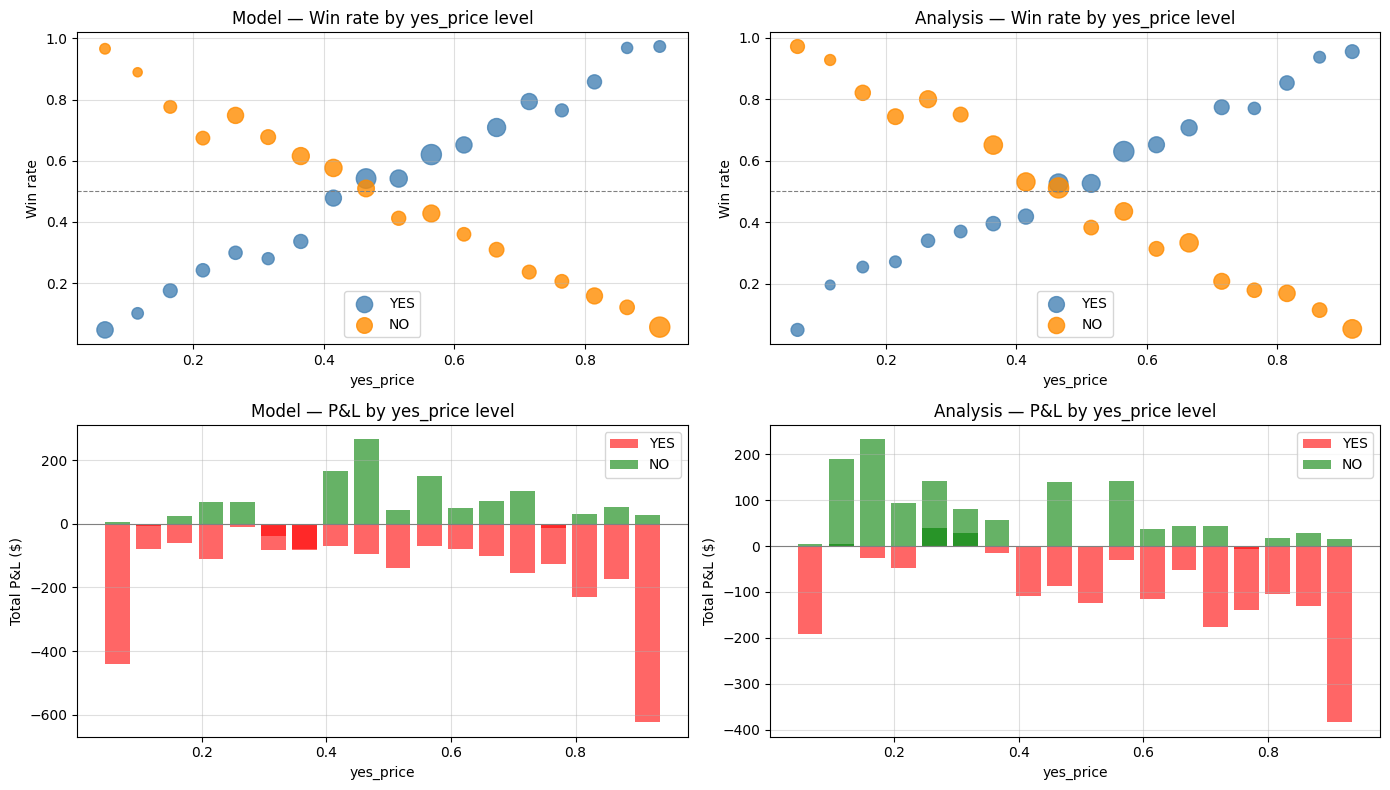

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col_i, (df, label) in enumerate([(model, 'Model'), (analysis, 'Analysis')]):
    df = df.copy()
    df['price_bin'] = pd.cut(df['yes_price'], bins=np.arange(0.04, 0.98, 0.05))
    df['price_mid'] = df['price_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)

    for side, color in [('YES', 'steelblue'), ('NO', 'darkorange')]:
        sub = df[df['side'] == side].dropna(subset=['price_bin'])
        if len(sub) == 0:
            continue
        grp = sub.groupby('price_bin', observed=True).agg(
            n=('won', 'count'), win_rate=('won', 'mean'), pnl=('pnl', 'sum'), mid=('price_mid', 'first')
        ).reset_index().dropna()
        axes[0][col_i].scatter(grp['mid'], grp['win_rate'],
                               s=grp['n']/max(grp['n'].max(), 1)*200+10,
                               color=color, alpha=0.8, label=side)
        bar_colors = ['green' if p >= 0 else 'red' for p in grp['pnl']]
        axes[1][col_i].bar(grp['mid'], grp['pnl'], width=0.04, color=bar_colors, alpha=0.6, label=side)

    axes[0][col_i].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    axes[0][col_i].set_title(f'{label} — Win rate by yes_price level')
    axes[0][col_i].set_xlabel('yes_price')
    axes[0][col_i].set_ylabel('Win rate')
    axes[0][col_i].legend()

    axes[1][col_i].axhline(0, color='gray', linewidth=0.8)
    axes[1][col_i].set_title(f'{label} — P&L by yes_price level')
    axes[1][col_i].set_xlabel('yes_price')
    axes[1][col_i].set_ylabel('Total P&L ($)')
    axes[1][col_i].legend()

plt.tight_layout()
plt.show()

## 7. YES vs NO breakdown
Are NO trades systematically better or worse than YES trades?

                                 trades    win%  total_pnl     roi  avg_edge  avg_pred
-------------------------------------------------------------------------------------
Model YES                        19,507   53.2%    +427.57   +2.2%   +0.0892     0.585
Model NO                         15,794   42.3%   -1829.49  -11.6%   +0.0851     0.542
Model ALL                        35,301   48.3%   -1401.92   -4.0%   +0.0874     0.566

Analysis YES                     13,930   56.7%   +1056.80   +7.6%   +0.1060     0.631
Analysis NO                      11,560   46.1%   -1295.51  -11.2%   +0.1029     0.590
Analysis ALL                     25,490   51.9%    -238.71   -0.9%   +0.1046     0.613



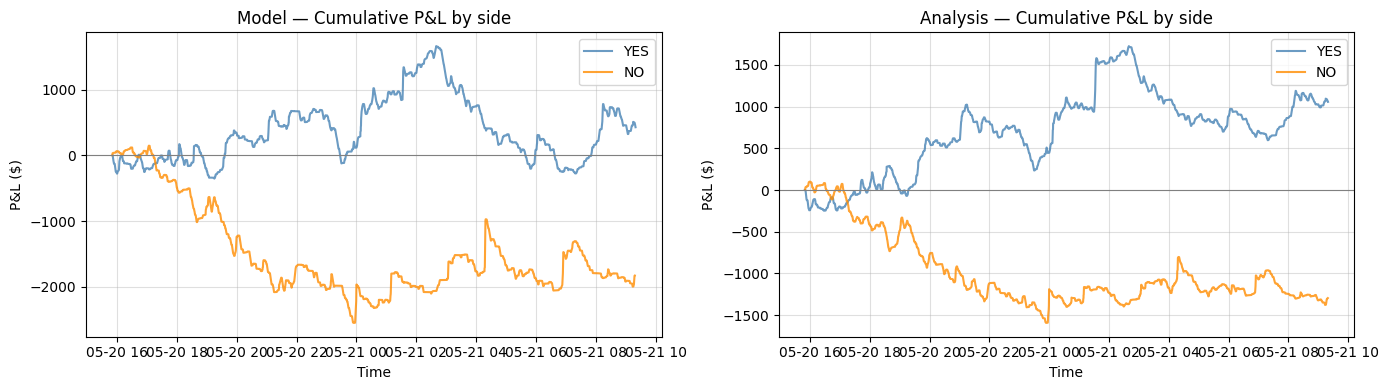

In [9]:
print(f"{'':30s} {'trades':>8} {'win%':>7} {'total_pnl':>10} {'roi':>7} {'avg_edge':>9} {'avg_pred':>9}")
print('-' * 85)
for df, label in [(model, 'Model'), (analysis, 'Analysis')]:
    for side in ['YES', 'NO', 'ALL']:
        sub = df if side == 'ALL' else df[df['side'] == side]
        if len(sub) == 0:
            continue
        pnl = sub['pnl'].sum()
        roi = 100 * pnl / len(sub)
        print(f"{f'{label} {side}':30s} {len(sub):>8,} {100*sub['won'].mean():>6.1f}% "
              f"{pnl:>+10.2f} {roi:>+6.1f}% {sub['edge'].mean():>+9.4f} {sub['predicted_prob'].mean():>9.3f}")
    print()

# cumulative P&L by side over time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, label in [(axes[0], model, 'Model'), (axes[1], analysis, 'Analysis')]:
    for side, color in [('YES', 'steelblue'), ('NO', 'darkorange')]:
        sub = df[df['side'] == side].sort_values('opened_at')
        if len(sub) == 0:
            continue
        ax.plot(sub['opened_at'], sub['pnl'].cumsum(), color=color, label=side, alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_title(f'{label} — Cumulative P&L by side')
    ax.set_xlabel('Time')
    ax.set_ylabel('P&L ($)')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Edge × time heatmap
2D view: which (edge bucket, time bucket) combinations are profitable?

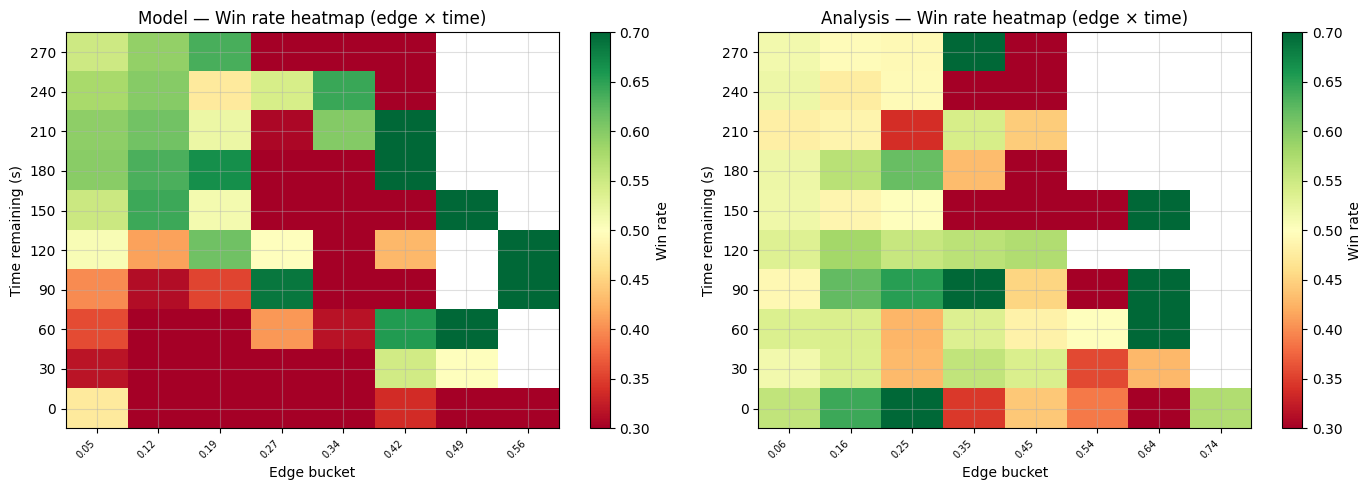

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label in [(axes[0], model, 'Model'), (axes[1], analysis, 'Analysis')]:
    df = df.copy()
    df['t_bucket'] = (df['time_remaining'] // 30) * 30
    df['edge_bucket'] = pd.cut(df['edge'], bins=8)

    pivot = df.groupby(['t_bucket', 'edge_bucket'], observed=True)['won'].mean().unstack('edge_bucket')
    if pivot.empty:
        continue

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0.3, vmax=0.7,
                   origin='lower')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{b.mid:.2f}" for b in pivot.columns], rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index.astype(int))
    ax.set_xlabel('Edge bucket')
    ax.set_ylabel('Time remaining (s)')
    ax.set_title(f'{label} — Win rate heatmap (edge × time)')
    plt.colorbar(im, ax=ax, label='Win rate')

plt.tight_layout()
plt.show()

## 9. Edge realisation — did predicted edge materialise?
Compare predicted edge vs actual P&L per unit stake, by edge bucket.

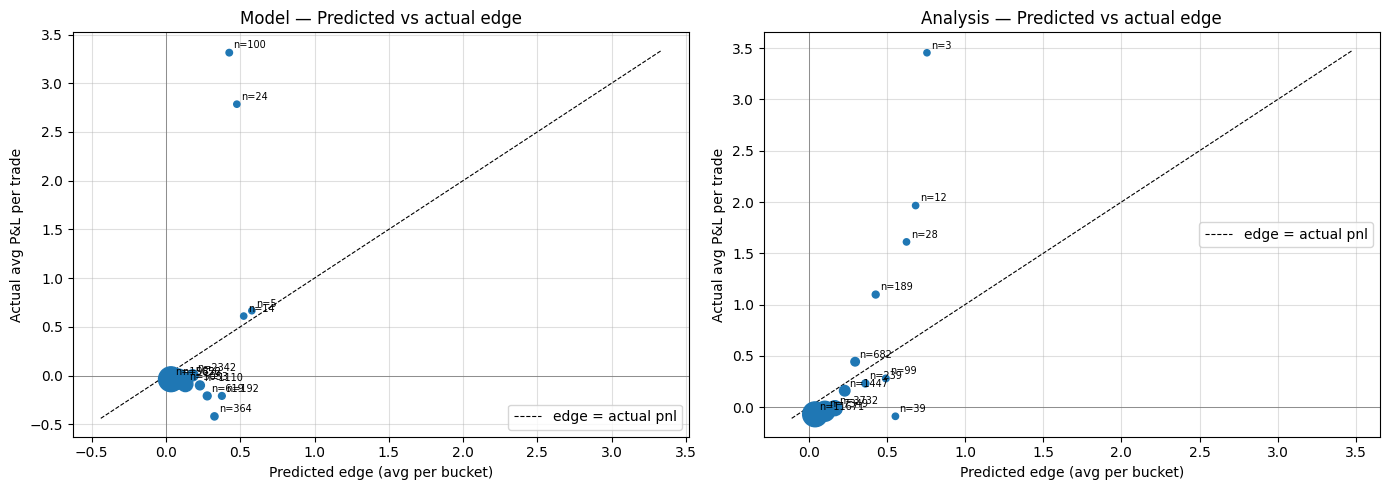

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label in [(axes[0], model, 'Model'), (axes[1], analysis, 'Analysis')]:
    df = df.copy()
    df['edge_bin'] = pd.cut(df['edge'], bins=12)
    grp = df.groupby('edge_bin', observed=True).agg(
        n=('pnl', 'count'),
        avg_predicted_edge=('edge', 'mean'),
        avg_actual_pnl=('pnl', 'mean'),
    ).dropna()

    ax.scatter(grp['avg_predicted_edge'], grp['avg_actual_pnl'],
               s=grp['n']/grp['n'].max()*300+20, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(f"n={int(row['n'])}",
                    (row['avg_predicted_edge'], row['avg_actual_pnl']),
                    xytext=(3, 3), textcoords='offset points', fontsize=7)

    lims = [min(grp['avg_predicted_edge'].min(), grp['avg_actual_pnl'].min()) - 0.02,
            max(grp['avg_predicted_edge'].max(), grp['avg_actual_pnl'].max()) + 0.02]
    ax.plot(lims, lims, 'k--', linewidth=0.8, label='edge = actual pnl')
    ax.axhline(0, color='gray', linewidth=0.6)
    ax.axvline(0, color='gray', linewidth=0.6)
    ax.set_xlabel('Predicted edge (avg per bucket)')
    ax.set_ylabel('Actual avg P&L per trade')
    ax.set_title(f'{label} — Predicted vs actual edge')
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
model.columns

Index(['trade_id', 'opened_at', 'market_id', 'yes_price', 'no_price',
       'btc_usd', 'pct_change_open', 'time_remaining', 'spread', 'side',
       'predicted_prob', 'edge', 'model_id', 'stake', 'resolved_yes',
       'resolved_at', 'pnl', 'won'],
      dtype='str')

In [14]:
from ipywidgets import interact, FloatSlider, IntSlider, fixed
import ipywidgets as widgets

def apply_filters(df, min_yes_price, max_edge, min_time_remaining):
    return df[
        (df['side'] == 'YES') &
        (df['yes_price'] >= min_yes_price) &
        (df['time_remaining'] >= min_time_remaining) &
        (df['edge'] <= max_edge) &
        (df['pct_change_open'] != 0.0)
    ].sort_values('opened_at')

def explore(min_yes_price, max_edge, min_time_remaining):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax_summary, ax_curve, (df, label) in [
        (axes[0], axes[1], (model, 'Model')),
        (axes[0], axes[2], (analysis, 'Analysis')),
    ]:
        filtered = apply_filters(df, min_yes_price, max_edge, min_time_remaining)
        n = len(filtered)
        pnl = filtered['pnl'].sum()
        win_rate = filtered['won'].mean() if n > 0 else 0
        roi = 100 * pnl / n if n > 0 else 0
        candles = filtered['market_id'].nunique()

        print(f"{label}: trades={n:,}  candles={candles}  win={100*win_rate:.1f}%  "
              f"pnl=${pnl:+.2f}  roi={roi:+.2f}%/trade")

        if n > 0:
            ax_curve.plot(filtered['opened_at'], filtered['pnl'].cumsum(), label=label)
            ax_curve.axhline(0, color='gray', linewidth=0.8)
            ax_curve.set_title(f'{label} — Cumulative P&L')
            ax_curve.set_xlabel('Time')
            ax_curve.set_ylabel('P&L ($)')

    # bar summary
    results = []
    for df, label in [(model, 'Model'), (analysis, 'Analysis')]:
        f = apply_filters(df, min_yes_price, max_edge, min_time_remaining)
        results.append((label, len(f), f['pnl'].sum() if len(f) > 0 else 0))

    labels = [r[0] for r in results]
    pnls   = [r[2] for r in results]
    counts = [r[1] for r in results]
    colors = ['green' if p >= 0 else 'red' for p in pnls]

    ax1 = axes[0]
    bars = ax1.bar(labels, pnls, color=colors, alpha=0.7)
    ax1.axhline(0, color='gray', linewidth=0.8)
    ax1.set_title('Total P&L')
    ax1.set_ylabel('P&L ($)')
    for bar, c in zip(bars, counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'n={c:,}', ha='center',
                 va='bottom' if bar.get_height() >= 0 else 'top', fontsize=9)

    plt.suptitle(
        f'Filters: side=YES  yes_price≥{min_yes_price:.2f}  '
        f'edge≤{max_edge:.2f}  time_remaining≥{min_time_remaining}s  pct≠0',
        fontsize=10, y=1.02
    )
    plt.tight_layout()
    plt.show()

interact(
    explore,
    min_yes_price=FloatSlider(value=0.40, min=0.04, max=0.80, step=0.05, description='min yes_price'),
    max_edge=FloatSlider(value=0.15, min=0.01, max=0.60, step=0.01, description='max edge'),
    min_time_remaining=IntSlider(value=100, min=15, max=285, step=15, description='min time_rem'),
)

interactive(children=(FloatSlider(value=0.4, description='min yes_price', max=0.8, min=0.04, step=0.05), Float…

<function __main__.explore(min_yes_price, max_edge, min_time_remaining)>